In [1]:
import os
import warnings
import joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

In [2]:
DATA_PATH    = "smart_home_clean.csv"
MODELS_DIR   = "models"
os.makedirs(MODELS_DIR, exist_ok=True)

N_ESTIMATORS = 200
RANDOM_STATE = 42
TEST_SIZE    = 0.2
BASELINE_R2  = 0.757  
TARGET       = 'Energy Consumption (kWh)'

print("Configuration OK")

Configuration OK


## 2. Chargement des données

In [3]:
df = pd.read_csv(r"C:\Users\Kenza\Downloads\EcoGuardian1-main (4)\EcoGuardian1-main\data\energy_dataset_clean.csv")

print(f"Shape     : {df.shape}")
print(f"Colonnes  : {list(df.columns)}")
print(f"NaN total : {df.isna().sum().sum()}")
df.head()

Shape     : (87600, 23)
Colonnes  : ['Timestamp', 'Household_Size', 'Daily_Energy_Consumption_kWh', 'Weather_Temperature', 'DayOfWeek', 'Is_Weekend', 'Temp_x_Size', 'Is_HVAC', 'Is_Cold_Season', 'Is_Hot_Season', 'Appliance_Type_Dishwasher', 'Appliance_Type_Dryer', 'Appliance_Type_Electric_Vehicle_Charger', 'Appliance_Type_Fridge', 'Appliance_Type_HVAC', 'Appliance_Type_Lighting', 'Appliance_Type_Microwave', 'Appliance_Type_Oven', 'Appliance_Type_TV', 'Appliance_Type_Washing_Machine', 'Appliance_Type_Water_Heater', 'Occupancy_Pattern_Evening', 'Occupancy_Pattern_Mixed']
NaN total : 0


,Timestamp,Household_Size,Daily_Energy_Consumption_kWh,Weather_Temperature,DayOfWeek,Is_Weekend,Temp_x_Size,Is_HVAC,Is_Cold_Season,Is_Hot_Season,...,Appliance_Type_Fridge,Appliance_Type_HVAC,Appliance_Type_Lighting,Appliance_Type_Microwave,Appliance_Type_Oven,Appliance_Type_TV,Appliance_Type_Washing_Machine,Appliance_Type_Water_Heater,Occupancy_Pattern_Evening,Occupancy_Pattern_Mixed
0,2025-01-01 08:09:00,41,5.39,-1.3,2,0,-53.3,0,1,0,...,1,0,0,0,0,0,0,0,0,0
1,2025-01-01 08:09:00,41,11.76,-1.3,2,0,-53.3,0,1,0,...,0,0,0,0,1,0,0,0,0,0
2,2025-01-01 08:09:00,41,6.99,-1.3,2,0,-53.3,0,1,0,...,0,0,0,0,0,0,1,0,0,0
3,2025-01-01 08:09:00,41,4.64,-1.3,2,0,-53.3,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,2025-01-01 08:09:00,41,48.74,-1.3,2,0,-53.3,1,1,0,...,0,1,0,0,0,0,0,0,0,0


 Feature Engineering

On enrichit le dataset avec :
- **Features cycliques (sin/cos)** : capturent la périodicité du temps (ex : 23h est proche de 0h)
- **Interactions température** : effets non-linéaires et combinés avec le contexte du foyer
- **Lag features** : consommation passée (1h et 24h avant)
- **Statistiques glissantes** : tendance et variabilité sur les dernières 24h

In [4]:
print(df.columns)

Index(['Timestamp', 'Household_Size', 'Daily_Energy_Consumption_kWh',
       'Weather_Temperature', 'DayOfWeek', 'Is_Weekend', 'Temp_x_Size',
       'Is_HVAC', 'Is_Cold_Season', 'Is_Hot_Season',
       'Appliance_Type_Dishwasher', 'Appliance_Type_Dryer',
       'Appliance_Type_Electric_Vehicle_Charger', 'Appliance_Type_Fridge',
       'Appliance_Type_HVAC', 'Appliance_Type_Lighting',
       'Appliance_Type_Microwave', 'Appliance_Type_Oven', 'Appliance_Type_TV',
       'Appliance_Type_Washing_Machine', 'Appliance_Type_Water_Heater',
       'Occupancy_Pattern_Evening', 'Occupancy_Pattern_Mixed'],
      dtype='object')


In [5]:
# Transformer Timestamp en datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Extraire les composantes temporelles
df['hour'] = df['Timestamp'].dt.hour
df['day_of_week'] = df['Timestamp'].dt.dayofweek
df['month'] = df['Timestamp'].dt.month

print("Colonnes temporelles créées ")

Colonnes temporelles créées 


In [6]:
df['hour_sin']  = np.sin(2 * np.pi * df['hour']        / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour']        / 24)
df['day_sin']   = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos']   = np.cos(2 * np.pi * df['day_of_week'] / 7)
df['month_sin'] = np.sin(2 * np.pi * df['month']       / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month']       / 12)

print("Encodage cyclique créé")

Encodage cyclique créé


In [7]:
temp = df['Weather_Temperature']

df['temp_squared'] = temp ** 2
df['temp_household_interaction'] = temp * df['Household_Size']
df['hour_temp_interaction'] = df['hour'] * temp

print("Interactions température créées ")

Interactions température créées 


In [8]:
TARGET = "Daily_Energy_Consumption_kWh"
df['consumption_lag_1h']  = df[TARGET].shift(1)   
df['consumption_lag_24h'] = df[TARGET].shift(24)  

print(" Lag features créées")

 Lag features créées


In [9]:
df['rolling_mean_24h'] = df[TARGET].rolling(24).mean()
df['rolling_std_24h']  = df[TARGET].rolling(24).std()

print(f" Statistiques glissantes créées — total colonnes : {len(df.columns)}")

 Statistiques glissantes créées — total colonnes : 39


## 4. Préparation des données (X / y / split)

In [10]:
FEATURE_COLS = [
   
    'Outdoor Temperature (°C)', 'Household Size', 'season_encoded',
    'Appliance_Type_Label', 'weekday',
    'hour', 'day_of_week', 'month',
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
    'temp_squared', 'temp_household_interaction', 'hour_temp_interaction',
    'consumption_lag_1h', 'consumption_lag_24h',
    'rolling_mean_24h', 'rolling_std_24h',
]

features = [f for f in FEATURE_COLS if f in df.columns]
missing  = [f for f in FEATURE_COLS if f not in df.columns]
if missing:
    print(f"  Colonnes manquantes ignorées : {missing}")

print(f" {len(features)} features sélectionnées")

  Colonnes manquantes ignorées : ['Outdoor Temperature (°C)', 'Household Size', 'season_encoded', 'Appliance_Type_Label', 'weekday']
 16 features sélectionnées


In [11]:
df_clean = df[features + [TARGET]].dropna()
print(f"Lignes après nettoyage : {len(df_clean):,}  ({len(df) - len(df_clean)} supprimées)")

X = df_clean[features]
y = df_clean[TARGET]

Lignes après nettoyage : 87,576  (24 supprimées)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (70060, 16)
Test set: (17516, 16)


 Entraînement des modèles

In [13]:
models = {
    'Random Forest': RandomForestRegressor(
        n_estimators=200, random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200, random_state=42
    ),
    'XGBoost': XGBRegressor(
        n_estimators=200, random_state=42, n_jobs=-1, verbosity=0
    ),
    'Ensemble (Voting)': VotingRegressor([
        ('gb',  GradientBoostingRegressor(n_estimators=200, random_state=42)),
        ('rf',  RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)),
        ('xgb', XGBRegressor(n_estimators=200, random_state=42, n_jobs=-1, verbosity=0)),
    ], weights=[0.4, 0.3, 0.3]),
}

In [14]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    print(f"  {name} ...", end=' ', flush=True)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    metrics = {
        'Model': name,
        'R²':   round(r2_score(y_te, y_pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_te, y_pred)), 4),
        'MAE':  round(mean_absolute_error(y_te, y_pred), 4),
    }
    print(f"R²={metrics['R²']:.4f}  RMSE={metrics['RMSE']:.4f}  MAE={metrics['MAE']:.4f}")
    return metrics

In [15]:
print("Entraînement des modèles...")
results = [
    evaluate_model(name, model, X_train, X_test, y_train, y_test)
    for name, model in models.items()
]

results_df = pd.DataFrame(results).sort_values('R²', ascending=False).reset_index(drop=True)
print("\n Comparaison des modèles :")
print(results_df.to_string(index=False))

Entraînement des modèles...
  Random Forest ... R²=0.9399  RMSE=2.1027  MAE=0.9665
  Gradient Boosting ... R²=0.7901  RMSE=3.9310  MAE=2.2412
  XGBoost ... R²=0.9298  RMSE=2.2738  MAE=1.2604
  Ensemble (Voting) ... R²=0.9104  RMSE=2.5687  MAE=1.3832

 Comparaison des modèles :
            Model     R²   RMSE    MAE
    Random Forest 0.9399 2.1027 0.9665
          XGBoost 0.9298 2.2738 1.2604
Ensemble (Voting) 0.9104 2.5687 1.3832
Gradient Boosting 0.7901 3.9310 2.2412


 Évaluation & Visualisation

In [16]:
# Récupération du meilleur modèle
best_name   = results_df.iloc[0]['Model']
best_r2     = results_df.iloc[0]['R²']
best_model  = models[best_name]
BASELINE_R2 = BASELINE_R2
improvement = (best_r2 - BASELINE_R2) / BASELINE_R2 * 100

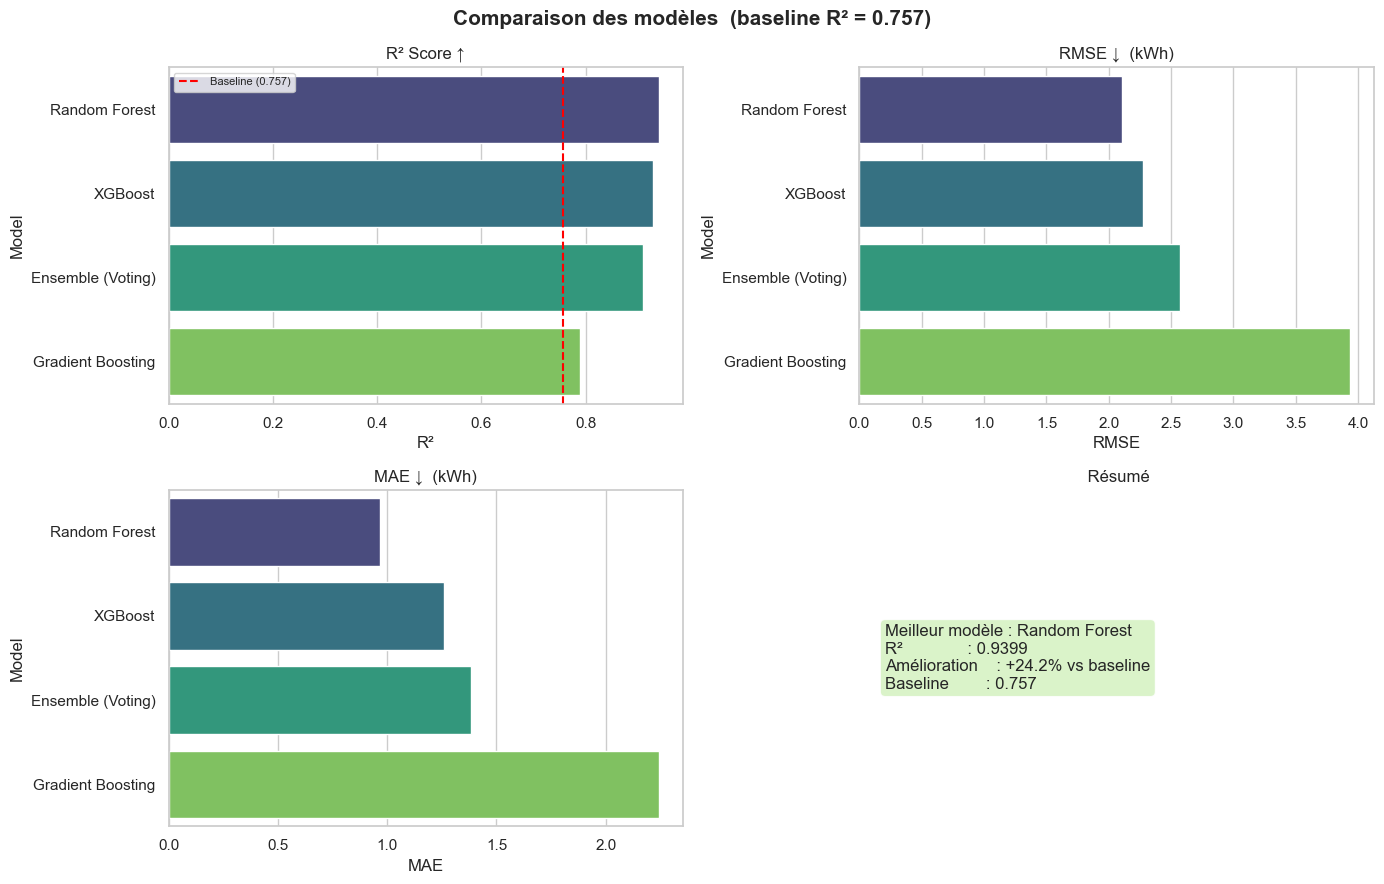

In [17]:
# Visualisation comparative des métriques de tous les modèles
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(f'Comparaison des modèles  (baseline R² = {BASELINE_R2})', fontsize=15, weight='bold')
palette = sns.color_palette('viridis', len(results_df))

sns.barplot(data=results_df, x='R²', y='Model', palette=palette, ax=axes[0, 0])
axes[0, 0].axvline(BASELINE_R2, color='red', linestyle='--', label=f'Baseline ({BASELINE_R2})')
axes[0, 0].set_title('R² Score ↑')
axes[0, 0].legend(fontsize=8)

sns.barplot(data=results_df, x='RMSE', y='Model', palette=palette, ax=axes[0, 1])
axes[0, 1].set_title('RMSE ↓  (kWh)')

sns.barplot(data=results_df, x='MAE', y='Model', palette=palette, ax=axes[1, 0])
axes[1, 0].set_title('MAE ↓  (kWh)')

summary = (
    f"Meilleur modèle : {best_name}\n"
    f"R²              : {best_r2:.4f}\n"
    f"Amélioration    : {improvement:+.1f}% vs baseline\n"
    f"Baseline        : {BASELINE_R2}"
)
axes[1, 1].text(0.05, 0.5, summary, fontsize=12, va='center',
                bbox=dict(boxstyle='round', facecolor='#d4f1c0', alpha=0.85))
axes[1, 1].axis('off')
axes[1, 1].set_title(' Résumé')

plt.tight_layout()
plt.show()

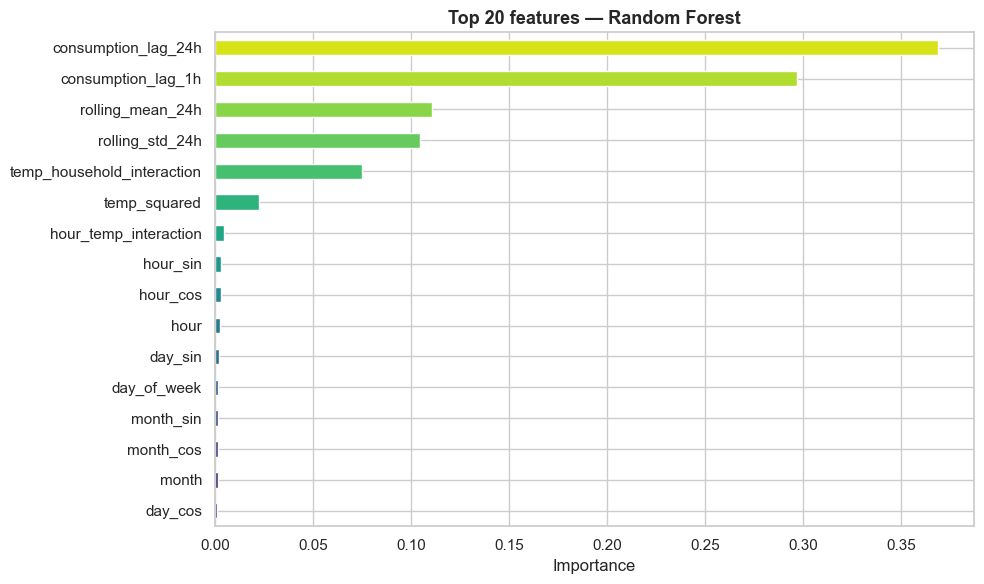

In [18]:
# Importance des features pour le meilleur modèle (disponible sur les modèles à base d'arbres)
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=features)
    top20 = importances.nlargest(20).sort_values()

    fig, ax = plt.subplots(figsize=(10, 6))
    top20.plot.barh(ax=ax, color=sns.color_palette('viridis', len(top20)))
    ax.set_title(f'Top 20 features — {best_name}', fontsize=13, weight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print("Feature importances non disponibles pour ce type de modèle.")

 Sauvegarde du meilleur modèle

In [19]:
from pathlib import Path

BASE_DIR = Path(r"C:\Users\Kenza\Downloads\EcoGuardian1-main (4)\EcoGuardian1-main\backend").resolve()

MODELS_DIR = BASE_DIR / "app" / "ml" / "models"

model_path    = MODELS_DIR / "smart_home_model.pkl"
features_path = MODELS_DIR / "smart_home_features.pkl"

print("BASE_DIR resolved to:", BASE_DIR)
print("Model path:", model_path)
print("Features path:", features_path)

joblib.dump(best_model, model_path)
joblib.dump(features, features_path)



print(f"Modèle sauvegardé      : {model_path}")
print(f"Features sauvegardées  : {features_path}")
print(f"\n Modèle : {best_name}")
print(f"R²     : {best_r2:.4f}  (amélioration : {improvement:+.1f}% vs baseline)")

BASE_DIR resolved to: C:\Users\Kenza\Downloads\EcoGuardian1-main (4)\EcoGuardian1-main\backend
Model path: C:\Users\Kenza\Downloads\EcoGuardian1-main (4)\EcoGuardian1-main\backend\app\ml\models\smart_home_model.pkl
Features path: C:\Users\Kenza\Downloads\EcoGuardian1-main (4)\EcoGuardian1-main\backend\app\ml\models\smart_home_features.pkl
Modèle sauvegardé      : C:\Users\Kenza\Downloads\EcoGuardian1-main (4)\EcoGuardian1-main\backend\app\ml\models\smart_home_model.pkl
Features sauvegardées  : C:\Users\Kenza\Downloads\EcoGuardian1-main (4)\EcoGuardian1-main\backend\app\ml\models\smart_home_features.pkl

 Modèle : Random Forest
R²     : 0.9399  (amélioration : +24.2% vs baseline)
